## 1. What this notebook computes

This notebook checks the honesty ledger of the book: the table that gives every
main statement of the book its label (PROVED, COMPUTED, ASSUMED, HYPOTHESIS or
OPEN) and the place where it is verified. It does what a careful reader would do
by hand, but for every report at once. It

- opens one report of the Revision record and reads its checks one by one;
- writes a function that counts the checks of a report in each of the three
  layouts that occur, searches the whole folder Revision for reports, finds 39,
  and counts the checks of all of them;
- confirms that no check has the verdict FAIL (every check is PASS except five
  comparisons with the author's own outputs that could not be made, verdict
  NOT-AVAILABLE) and that the counts agree with the summaries that the reports
  state themselves, with the table of the file Revision/README.md, with the
  counts quoted by the Kohn-Sham cross-check and with the dark-sector summary;
- assigns every report to its row of the ledger, and prints the list of what the
  pairing record itself says is NOT established;
- computes sha256 fingerprints and compares the 24 fingerprints that the reports
  recorded for their input files with the files of today;
- draws four teaching plots and prints a PASS line for every check.

It does not run the verifier programs again (they need Wolfram Mathematica or Rust
and minutes to hours); it checks what they recorded.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 00c (The honesty ledger: reading and checking the Revision record) is the file
`Revision/textbook/notebooks/00c_honesty_ledger.ipynb` of the repository Dirac_claude. It
finds the 39 verifier reports of the Revision record, counts their checks and confirms
that none has the verdict FAIL (all are PASS except five comparisons with the author's
outputs that are NOT-AVAILABLE), compares the counts with the summaries of the reports
and with the numbers quoted elsewhere in the record, assigns every report to its row of
the honesty ledger with the labels PROVED, COMPUTED, ASSUMED, HYPOTHESIS and OPEN, prints
what the pairing record itself says is not established, compares 24 recorded sha256
fingerprints with the files of today, and draws four teaching plots. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 00c_honesty_ledger.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 00c_honesty_ledger.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
00c_honesty_ledger.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/00c.captions.json`
- `Revision/textbook/figures/00c_1_checks_by_report.png`
- `Revision/textbook/figures/00c_2_two_verifiers.png`
- `Revision/textbook/figures/00c_3_ledger.png`
- `Revision/textbook/figures/00c_4_fingerprints.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the four figure files of this notebook exist
    ALL 18 CHECKS PASSED (notebook 00c)

and the notebook must show 4 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/00c_honesty_ledger.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 00c_honesty_ledger.ipynb
      python -m nbconvert --execute --inplace 00c_honesty_ledger.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" or "KeyError" naming a file below the folder Revision: a file of
  the Revision record is missing or damaged: the repository folder is incomplete. Delete
  the folder Dirac_claude, download it again with the git clone command of Step 3, and
  open the notebook from the new folder.
- "AssertionError: check failed: the 24 recorded fingerprints equal the files of today":
  a file of the Revision record was changed after its report was written; the table
  printed just above the error marks it CHANGED. The command below, run in the repository
  folder, lists every changed file; restore a changed file with the second command (write
  the file name printed in the table, with the folder Revision in front, instead of
  FILE).

      git status
      git restore FILE

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 00c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 00c (The honesty ledger: reading and checking the Revision record) is the file
# Revision/textbook/notebooks/00c_honesty_ledger.ipynb of the repository Dirac_claude. It
# finds the 39 verifier reports of the Revision record, counts their checks and confirms
# that none has the verdict FAIL (all are PASS except five comparisons with the author's
# outputs that are NOT-AVAILABLE), compares the counts with the summaries of the reports
# and with the numbers quoted elsewhere in the record, assigns every report to its row of
# the honesty ledger with the labels PROVED, COMPUTED, ASSUMED, HYPOTHESIS and OPEN,
# prints what the pairing record itself says is not established, compares 24 recorded
# sha256 fingerprints with the files of today, and draws four teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 00c_honesty_ledger.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 00c_honesty_ledger.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 00c_honesty_ledger.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/00c.captions.json
# - Revision/textbook/figures/00c_1_checks_by_report.png
# - Revision/textbook/figures/00c_2_two_verifiers.png
# - Revision/textbook/figures/00c_3_ledger.png
# - Revision/textbook/figures/00c_4_fingerprints.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the four figure files of this notebook exist
#     ALL 18 CHECKS PASSED (notebook 00c)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/00c_honesty_ledger.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 00c_honesty_ledger.ipynb
#     python -m nbconvert --execute --inplace 00c_honesty_ledger.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" or "KeyError" naming a file below the folder Revision: a file of
#   the Revision record is missing or damaged: the repository folder is incomplete.
#   Delete the folder Dirac_claude, download it again with the git clone command of Step
#   3, and open the notebook from the new folder.
# - "AssertionError: check failed: the 24 recorded fingerprints equal the files of
#   today": a file of the Revision record was changed after its report was written; the
#   table printed just above the error marks it CHANGED. The command below, run in the
#   repository folder, lists every changed file; restore a changed file with the second
#   command (write the file name printed in the table, with the folder Revision in front,
#   instead of FILE).
#     git status
#     git restore FILE
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "00c"  # this notebook: chapter 00, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 00c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Revision record**: the computations stored in the folder Revision of the
  repository, done anew for the author's metric. Every number of the book comes
  from it or from a notebook of the book.
- **Verifier, report**: a *verifier* is a program that checks statements; it writes
  its results into a *report*, a JSON file (a plain text file of names, numbers and
  lists).
- **Check, verdict**: a *check* is one statement tested by a verifier; its *verdict*
  is PASS (true) or FAIL (false). Each check also has a name and a detail text.
- **Engine**: the program that did the computation: **Wolfram Language** (the
  language of Mathematica, run with wolframscript), **Python** (with the packages
  sympy, numpy and mpmath), or **Rust** (a fast compiled language). The *lead's
  independent checks* are short Python programs that share no code with the other
  verifiers.
- **Independent**: two verifiers are independent when they share no code; when both
  agree, a programming error in one of them would have to be repeated in the other
  to go unnoticed.
- **Dictionary, list** (Python): a *list* `[a, b, c]` is an ordered collection; a
  *dictionary* `{"name": value, ...}` stores values under names (*keys*). A JSON
  file is read into dictionaries and lists.
- **The five labels**: **PROVED** (exact; the book gives the complete proof and,
  where the Revision record contains an exact computer check of the statement,
  names the report file and the check), **COMPUTED** (a number from a numerical
  computation, with its measured uncertainty and the file that holds it),
  **ASSUMED** (a starting point that the book does not derive: a convention, a
  physical input or an approximation), **HYPOTHESIS** (an idea that is stated and
  examined but not established), **OPEN** (a question that neither the Revision
  record nor the book answers).
- **Ledger**: the table of the statements, their labels and the reports that
  verify them.
- **Fingerprint (sha256)**: a number of 64 hexadecimal characters computed from the
  bytes of a file by a fixed recipe. The same file always gives the same
  fingerprint. A file that differs in a single byte has, in every case anyone has
  tried, a completely different one; this is not proved, and section 10 measures
  it for 115 changes. **Hexadecimal**: the digits 0 to 9 and the letters a to f,
  sixteen symbols in all.

## 4. The physical and mathematical situation

The rule above every other rule of the book is honesty: it never writes "proved"
for a statement that is not proved. To make this rule checkable, every statement
carries one of five labels and names the place where it is verified. A statement
can be checked at three levels:

1. **The derivation**: follow it line by line in the book.
2. **The report**: open the report of the verifier that checked it and read the
   verdict of the named check. This notebook works at this level.
3. **The computation**: run the verifier again and compare its new report with the
   stored one (the last chapter of the book lists every command).

Two facts make level 2 trustworthy. First, the exact statements of nine subjects
were checked by two independent verifiers, one in Wolfram Language and one in
Python, and the Kohn-Sham numbers by two independent solvers, one in Rust and one
in Python.
Second, a report records the sha256 fingerprints of the files it read; when the
fingerprints of today's files are the same, the report belongs to exactly these
files.

A ledger row labelled OPEN or HYPOTHESIS has no report: nothing in the record
establishes it. In particular the record proves exact maps between the solutions
of mass $+m$ and those of mass $-m$ (the pairing theorems T1, T2, Q and T3), but it
does not prove that the big bang creates universes, in pairs or otherwise, and the
theory as built does not explain the excess of matter over antimatter. It proves
that no charge is made or destroyed at any point (a *local* conservation law), but
not that the total charge of a universe stays constant. The pairing record states
itself what it does not establish; the notebook prints that list.

## 5. One report, opened by hand

The next cell defines the function `read_report`, which reads a JSON file of the
repository into Python dictionaries and lists, and the helper `check_reproduces`.
`check_reproduces` is the helper `check` for a check that reproduces a Revision
record: it first calls `sys.stdout.flush()`, which sends all printed text that is
still waiting, and then calls `check` with the record. (Jupyter sends printed text
in pieces; flushing first keeps the PASS line and the line `reproduces ...` below
it in one piece, so that the book's tools read them together.)

Then the cell opens the report of the lead's independent check of the
charge-conjugation matrices and of the local conservation law of the charge,
Revision/lead_checks/reports/charge-conjugation-and-u1.json. It prints the program
that wrote the report (its *producer*), the verdict and name of each of its 12
checks, and the summary that the report states about itself. The check confirms
that our count of the verdicts PASS equals that summary.

In [2]:
import hashlib  # computes sha256 fingerprints
import re  # finds patterns in texts ("regular expressions")
import sys  # sys.stdout is the channel through which the notebook prints

import numpy as np  # arrays of numbers


def read_report(path):
    """The content of the JSON file path of the repository (dictionaries, lists)."""
    return json.loads(repository_file(path).read_text(encoding="utf-8"))


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), after sending the waiting output."""
    sys.stdout.flush()  # send every printed line that is still waiting
    check(condition, name, record=record)


CC_REPORT = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
cc = read_report(CC_REPORT)  # a dictionary with the keys producer, summary, checks
producer = cc["producer"]
say(f"producer: {producer}")
for entry in cc["checks"]:  # each entry is a dictionary: name, verdict, detail
    verdict, name = entry["verdict"], entry["name"]
    say(f"  {verdict}  {name}")
stated = cc["summary"]  # what the report says about itself: passed and total
stated_passed, stated_total = stated["passed"], stated["total"]
say(f"the report states: {stated_passed} passed of {stated_total}")
passed = sum(1 for entry in cc["checks"] if entry["verdict"] == "PASS")
number_of_checks = len(cc["checks"])
report("checks with the verdict PASS, counted", f"{passed} of {number_of_checks}")
check_reproduces(passed == stated["passed"] == stated["total"] == 12,
                 "12 of 12 checks of the charge-conjugation report are PASS",
                 f"{CC_REPORT}, its summary")

producer: Revision/lead_checks/charge_conjugation_and_u1.py (lead, independent; no
    Revision code imported)
  PASS  representation_real
  PASS  B_imaginary_hermitian
  PASS  intertwiners_same_mass
  PASS  intertwiners_reversed_mass
  PASS  charge_conjugation_matrix_plus
  PASS  charge_conjugation_matrix_minus
  PASS  majorana_conditions_consistent
  PASS  bilinears_under_charge_conjugation
  PASS  quantum_charge_conjugation_unitary_type
  PASS  real_fields_charge_conjugation
  PASS  spinor_connection_real
  PASS  u1_noether_matrix_identity
the report states: 12 passed of 12
RESULT checks with the verdict PASS, counted = 12 of 12
PASS 12 of 12 checks of the charge-conjugation report are PASS
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, its summary


Every check also has a detail text that says exactly what was verified. The next
cell prints the details of five checks of the same report. They say, in the
report's own words, that the author's gamma matrices are real, so that plain
complex conjugation changes nothing at all in a real field (the charge conjugation
of the theory is a MATRIX, not plain complex conjugation); that the
charge-conjugation matrix which keeps the mass is $\mathcal{C}_+ = C$ and the one
which reverses the mass is $\mathcal{C}_- = \Gamma C$; that for a real commuting
field the charge current is zero and $\mathcal{C}_+$ acts as the identity, while
the real matrix $\Gamma$ with the mass reversed maps solutions to solutions; and
that the charge obeys a *local* conservation law: on every solution
$\partial_\mu(\cos z\, J^\mu) = 0$, so no charge is made or destroyed at any point.
The same detail says what this check does NOT establish: the total charge $Q$ of a
slice of space is constant only if no charge flows through its edge, the brane at
$z = \pi/2$, where the flow is not zero in general. (These statements are derived
from zero later in the book; the book labels the constancy of the total charge
OPEN.) The detail of the last check is long; the cell prints only its last two
parts, after the second-to-last semicolon, which state the result and its limit.
The details are long texts; `say` breaks each into lines of at most 89
characters. The two checks of the cell confirm that the details contain these
statements word for word.

In [3]:
details = {entry["name"]: entry["detail"] for entry in cc["checks"]}  # name -> detail
for wanted in ("representation_real", "charge_conjugation_matrix_plus",
               "charge_conjugation_matrix_minus", "real_fields_charge_conjugation",
               "u1_noether_matrix_identity"):
    detail = details[wanted]
    if wanted == "u1_noether_matrix_identity":
        # This detail is long; its last two parts, after the second-to-last "; ",
        # state the result and its limit.
        detail = "; ".join(detail.split("; ")[-2:])
    say(f"{wanted}:")
    say("    " + detail)  # say breaks it into lines of at most 89 characters

R5_WORDS = [  # (check, words that its detail must contain)
    ("representation_real", "plain complex conjugation is the identity"),
    ("charge_conjugation_matrix_plus", "calC_+ = C (= sigma16)"),
    ("charge_conjugation_matrix_plus", "Psi^c = calC_+ Psibar^T = Psi*"),
    ("charge_conjugation_matrix_minus", "calC_- = Gamma C"),
    ("charge_conjugation_matrix_minus", "Psi^c = calC_- Psibar^T = Gamma Psi*"),
    ("real_fields_charge_conjugation", "J^a = -i Psi^T C gamma^a Psi = 0"),
    ("real_fields_charge_conjugation", "calC_+ acts as the identity"),
    ("real_fields_charge_conjugation", "the matrix Gamma with the mass reversed"),
]
check_reproduces(all(words in details[name] for name, words in R5_WORDS),
                 "the report states calC_+ = C, calC_- = Gamma C and J = 0 for a "
                 "real field",
                 f"{CC_REPORT}, checks charge_conjugation_matrix_plus, "
                 "charge_conjugation_matrix_minus and real_fields_charge_conjugation")
U1_WORDS = ["on shell the LOCAL law d_mu(cos z J^mu) = 0 holds",
            "is constant only if no charge flows through its boundary",
            "constancy of Q is NOT established by this check"]
check_reproduces(all(words in details["u1_noether_matrix_identity"]
                     for words in U1_WORDS),
                 "the report proves the local law and does not establish a "
                 "constant total charge",
                 f"{CC_REPORT}, check u1_noether_matrix_identity")

representation_real:
    gamma^a, C (= sigma16, symmetric, C^2 = 1) and S^ab are real: plain complex
    conjugation is the identity on a real field
charge_conjugation_matrix_plus:
    calC_+ = C (= sigma16): calC_+^-1 gamma^a calC_+ = -(gamma^a)^T for every a; real
    symmetric; Psi^c = calC_+ Psibar^T = Psi*
charge_conjugation_matrix_minus:
    calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T for every a; real; Psi^c =
    calC_- Psibar^T = Gamma Psi* (solves the equation with V -> -V)
real_fields_charge_conjugation:
    real commuting Psi: J^a = -i Psi^T C gamma^a Psi = 0 identically and calC_+ acts as
    the identity (a real field is its own conjugate, no U(1) charge); the REAL matrix
    Gamma maps real fields to real fields, keeps S = Psi^T C Psi and reverses every
    kinetic matrix C gamma^a (Gamma^T C gamma^a Gamma = -C gamma^a): with m -> -m (and
    lambda -> -lambda) it maps solutions to solutions (T1) - for real fields the matter
    <-> antimatter map is the ma

## 6. Three layouts of a report, one counting function

The reports of the Revision record were written by different programs, and their
checks come in three layouts:

- **layout A**: `checks` is a list of dictionaries, each with a `name` and a
  `verdict` (written PASS or pass);
- **layout B**: `checks` is a dictionary from the name of each check to a
  dictionary with the entry `passed` (true or false);
- **layout C**: the self-test of the Rust function GKD has no `checks` but a list
  `results`, one per test, each with the number of `mismatches` (wrong values).

The reports also state their own totals in different words (`summary`, `counts`,
`checkCount`), and two of them as a text, such as "49/49 checks pass". The next
cell defines `count_checks`, which counts the passed checks in all three layouts,
and `stated_summary`, which reads the totals that a report states about itself.
It shows one report of each layout.

In [4]:
def count_checks(data):
    """(number of passed checks, number of checks), counted from the checks."""
    if isinstance(data.get("checks"), list):  # layout A
        verdicts = [entry["verdict"].upper() == "PASS" for entry in data["checks"]]
    elif isinstance(data.get("checks"), dict):  # layout B
        verdicts = [entry["passed"] is True for entry in data["checks"].values()]
    else:  # layout C: a self-test passes when it found no mismatch
        verdicts = [entry["mismatches"] == 0 for entry in data["results"]]
    # True counts as 1 and False as 0 when added.
    return sum(verdicts), len(verdicts)


def stated_summary(data):
    """(passed, total) as the report states them itself; None if it states none."""
    summary = data.get("summary")
    if isinstance(summary, dict):  # {"passed": n, "total": n} and similar names
        passed = summary.get("passed", summary.get("pass", summary.get("PASS")))
        return passed, summary.get("total", summary.get("checks"))
    if isinstance(summary, str):  # a text such as "49/49 checks pass"
        passed, total = re.fullmatch(r"(\d+)/(\d+) checks pass", summary).groups()
        return int(passed), int(total)
    counts = data.get("counts")
    if isinstance(counts, dict) and "pass" in counts:  # {"pass", "fail", "pending"}
        return counts["pass"], counts["pass"] + counts["fail"] + counts["pending"]
    if "checkCount" in data:  # a total and a number of failed checks
        failed = data.get("failCount", data.get("failedCount",
                                                 data.get("failedCheckCount")))
        return data["checkCount"] - failed, data["checkCount"]
    return None


EXAMPLES = [("A", "Revision/pairing/reports/wolfram-pairing.json"),
            ("B", "Revision/gkd_lovelock/results/lovelock-report.json"),
            ("C", "Revision/gkd_lovelock/results/gkd-selftest.json")]
for layout, path in EXAMPLES:
    data = read_report(path)
    passed, total = count_checks(data)
    say(f"layout {layout}: {path}")
    say(f"    counted {passed} of {total}; stated {stated_summary(data)}")

layout A: Revision/pairing/reports/wolfram-pairing.json
    counted 101 of 101; stated (101, 101)
layout B: Revision/gkd_lovelock/results/lovelock-report.json
    counted 19 of 19; stated (19, 19)
layout C: Revision/gkd_lovelock/results/gkd-selftest.json
    counted 9 of 9; stated None


## 7. All 39 reports of the Revision record

The next cell first searches the whole folder Revision for reports: JSON files
whose key `checks` holds the checks themselves (a list of checks, or a dictionary
whose every entry is a check, that is, a dictionary itself), or, like the GKD
self-test, a list `results` whose entries count `mismatches`. One JSON file has a
key `checks` that holds only two numbers, the totals of another report: the
summary file Revision/dark_sector/dirac16complex/outputs/eos-summary.json. It is
not a report, and the search prints its name; the cell after the next compares its
two numbers with our count. The search skips three kinds of folders that are not
part of the record: the folder Revision/textbook of this book, the folder
Revision/workflows (the records of the programs that organised the work, rewritten
while they run; the Revision record says itself that no result depends on them),
and the build folders `target` of the Rust programs. The cell then lists the 39
verifier reports of the Revision record, grouped by folder, each with its engine
(the language of the program that wrote the report), counts the checks of each with
`count_checks`, and prints a table and the totals per engine.

One report has checks whose verdict is neither PASS nor FAIL: the comparison of
the Revision's curvature with the outputs that the author stored in his own
Mathematica notebook, Revision/gkd_lovelock/comparison/author-comparison-report.json.
For five quantities the author's notebook holds no stored value (they are
computed there but not printed), so there is nothing to compare; their verdict is
NOT-AVAILABLE. Three checks follow:

1. the search finds exactly the 39 reports of the list: no report of the record is
   left out of the count (and so out of the ledger below);
2. no check of the 39 reports has the verdict FAIL: every check is PASS, except
   the five NOT-AVAILABLE comparisons of that one report;
3. for every report that states its own totals, our count equals them (the
   self-test of layout C states only its verdict, SUCCESS, which is checked
   instead).

`folder.rglob("*.json")` lists every JSON file in a folder and in all its
sub-folders; `path.as_posix()` writes a path with `/`; `path.removeprefix("Revision/")`
removes the folder name Revision/ from the front of a path, to keep the table
narrow. Reading every JSON file of the record (a few hundred files) takes about a
second.

In [5]:
def is_report(path):
    """True if the JSON file path (a Path) is a verifier report."""
    data = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(data, dict):
        return False
    checks = data.get("checks")
    listed = isinstance(checks, list) or (  # a list of checks, or a dictionary
        isinstance(checks, dict)  # whose every entry is a check (a dictionary)
        and all(isinstance(entry, dict) for entry in checks.values()))
    results = data.get("results")
    self_test = (isinstance(results, list) and len(results) > 0
                 and isinstance(results[0], dict) and "mismatches" in results[0])
    return listed or self_test


SKIPPED = ("Revision/textbook/", "Revision/workflows/")  # folders that hold no report
found_reports = []  # every report found in the folder Revision, as a relative path
not_reports = []  # JSON files with a key "checks" that holds no checks
for path in sorted(repository_file("Revision").rglob("*.json")):
    relative = path.relative_to(REPO).as_posix()  # e.g. "Revision/algebra/..."
    if relative.startswith(SKIPPED) or "/target/" in relative:
        continue  # the book, the workflow records and the Rust build folders
    if is_report(path):
        found_reports.append(relative)
    elif "checks" in read_report(relative):
        not_reports.append(relative)
report("verifier reports found in the folder Revision", len(found_reports))
say("JSON files with a key checks that holds no checks:")
for relative in not_reports:
    say("    " + relative)

REPORTS = [  # (report, engine)
    # the gammas, C, Gamma, B, Pin(4,4) and Spin(4,4)
    ("Revision/algebra/reports/wolfram-algebra.json", "Wolfram"),
    ("Revision/algebra/reports/python-algebra.json", "Python"),
    # the Lagrangians, field equations, EMT, quantisation; the scope
    ("Revision/theory/reports/wolfram-field-theory.json", "Wolfram"),
    ("Revision/theory/reports/python-field-theory.json", "Python"),
    ("Revision/theory/reports/wolfram-scope.json", "Wolfram"),
    ("Revision/theory/reports/python-scope.json", "Python"),
    # the field equations for a4; the Kohn-Sham states as a source
    ("Revision/field_equations_a4/reports/wolfram-a4-report.json", "Wolfram"),
    ("Revision/field_equations_a4/reports/python-a4-report.json", "Python"),
    ("Revision/field_equations_a4/reports/ks-source-conditions.json", "Python"),
    ("Revision/field_equations_a4/ks_source/reports/ks-source-a4.json", "Python"),
    # GKD and the Lovelock tensors; the comparison with the author's outputs
    ("Revision/gkd_lovelock/results/lovelock-report.json", "Rust"),
    ("Revision/gkd_lovelock/results/gkd-selftest.json", "Rust"),
    ("Revision/gkd_lovelock/results/wolfram-gkd-report.json", "Wolfram"),
    ("Revision/gkd_lovelock/results/python-lovelock-report.json", "Python"),
    ("Revision/gkd_lovelock/comparison/author-comparison-report.json", "Python"),
    # the Kohn-Sham theory, solvers and comparisons
    ("Revision/kohn_sham/reports/ks-theory-wolfram.json", "Wolfram"),
    ("Revision/kohn_sham/reports/ks-theory-python.json", "Python"),
    ("Revision/kohn_sham/reports/ks-rust-solver.json", "Rust"),
    ("Revision/kohn_sham/reports/ks-rust-determinism.json", "Python"),
    ("Revision/kohn_sham/reports/ks-rust-mermin-roots.json", "Python"),
    ("Revision/kohn_sham/reports/ks-reference.json", "Python"),
    ("Revision/kohn_sham/reports/ks-crosscheck.json", "Python"),
    # the dark-sector hypotheses of the two fields, investigated
    ("Revision/dark_sector/dirac16complex/reports/derivation-checks.json", "Python"),
    ("Revision/dark_sector/dirac16complex/reports/ks-history-run.json", "Python"),
    ("Revision/dark_sector/dirac16complex/reports/eos-checks.json", "Python"),
    ("Revision/dark_sector/dirac16complex/reports/independent-checks.json", "Python"),
    ("Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json", "Python"),
    ("Revision/dark_sector/dirac16complex00/reports/python-independent-numerics.json",
     "Python"),
    # the pairing theorems T1, T2, Q and T3; T3 completed and demonstrated
    ("Revision/pairing/reports/wolfram-pairing.json", "Wolfram"),
    ("Revision/pairing/reports/python-pairing.json", "Python"),
    ("Revision/pairing/kohn_sham/reports/wolfram-t3.json", "Wolfram"),
    ("Revision/pairing/kohn_sham/reports/python-t3.json", "Python"),
    ("Revision/pairing/kohn_sham/reports/wolfram-t3-completion.json", "Wolfram"),
    ("Revision/pairing/kohn_sham/reports/python-t3-completion.json", "Python"),
    ("Revision/pairing/kohn_sham/reports/t3-rust-demo.json", "Python"),
    ("Revision/pairing/kohn_sham/reports/t3-reference-demo.json", "Python"),
    # the lead's independent checks
    ("Revision/lead_checks/reports/charge-conjugation-and-u1.json", "lead"),
    ("Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json", "lead"),
    ("Revision/lead_checks/reports/emt-divergence-and-spin-connection.json", "lead"),
]
check(found_reports == sorted(path for path, _ in REPORTS),
      f"the search finds exactly the {len(REPORTS)} reports of the list")
counted = {}  # report -> (passed, total)
header = "report (in the folder Revision)"
say(f"{header:69} engine  pass of all")
for path, engine in REPORTS:
    data = read_report(path)
    counted[path] = count_checks(data)
    passed, total = counted[path]
    short = path.removeprefix("Revision/")
    say(f"{short:69} {engine:7} {passed:4d} of {total:3d}")
all_checks = sum(total for _, total in counted.values())
all_passed = sum(passed for passed, _ in counted.values())
report("reports", len(REPORTS))
report("checks in all reports", all_checks)
report("checks with the verdict PASS", all_passed)
engine_totals = {}  # engine -> the number of its checks
for engine in ("Wolfram", "Python", "Rust", "lead"):
    engine_totals[engine] = sum(counted[path][1] for path, e in REPORTS
                                if e == engine)
    report(f"checks done with the engine {engine}", engine_totals[engine])

COMPARISON = "Revision/gkd_lovelock/comparison/author-comparison-report.json"
not_pass = [path for path, _ in REPORTS if counted[path][0] != counted[path][1]]
other_verdicts = [entry["verdict"] for entry in read_report(COMPARISON)["checks"]
                  if entry["verdict"] != "PASS"]  # the verdicts that are not PASS
not_available = other_verdicts.count("NOT-AVAILABLE")
report("checks with the verdict NOT-AVAILABLE", not_available)
check(not_pass == [COMPARISON] and len(other_verdicts) == not_available == 5
      and all_passed + not_available == all_checks
      and sum(engine_totals.values()) == all_checks,
      f"no check FAILS: {all_passed} PASS, {not_available} NOT-AVAILABLE, "
      f"{all_checks} in all")
disagree = []  # reports whose own summary differs from our count
for path, _ in REPORTS:
    data = read_report(path)
    stated = stated_summary(data)
    if stated is None:  # layout C: the self-test states only its verdict
        stated = counted[path] if data["verdict"] == "SUCCESS" else None
    if stated != counted[path]:
        disagree.append(path)
check(disagree == [], "each report states the same totals that we counted")

RESULT verifier reports found in the folder Revision = 39
JSON files with a key checks that holds no checks:
    Revision/dark_sector/dirac16complex/outputs/eos-summary.json
PASS the search finds exactly the 39 reports of the list
report (in the folder Revision)                                       engine  pass of all
algebra/reports/wolfram-algebra.json                                  Wolfram   45 of  45
algebra/reports/python-algebra.json                                   Python    35 of  35
theory/reports/wolfram-field-theory.json                              Wolfram   84 of  84
theory/reports/python-field-theory.json                               Python    70 of  70
theory/reports/wolfram-scope.json                                     Wolfram   15 of  15
theory/reports/python-scope.json                                      Python    14 of  14
field_equations_a4/reports/wolfram-a4-report.json                     Wolfram   52 of  52
field_equations_a4/reports/python-a4-report.json 

The next cell compares our counts with three other places of the record that quote
them. First, the table of the file Revision/README.md (its lines that start with
a vertical bar and a folder name) prints 37 counts as "19/19", "49/49" and so on;
the counts of the reports on the Lovelock tensors stand there twice, in the row
of their folder and in the row of the documents. The cell finds the counts in the
order in which they stand there and compares them with our counts of the reports
that the table names in that order. The function `re.findall` of the module `re`
finds every piece of a text that matches a *pattern*: in the pattern
`(\d+)/(\d+)`, `\d+` means one or more digits, and the brackets mark the two
numbers to return. Second, the Kohn-Sham cross-check quotes, in the detail of its
check `inputs_all_pass`, the counts of the three reports it read ("37/37 PASS" and
so on), found with the pattern `(\d+)/(\d+) PASS`. Third, the dark-sector summary
file that the search set aside quotes, under its key `checks`, the totals of the
report eos-checks.json.

In [6]:
R = "Revision/"
README_ORDER = [  # the reports whose counts the README table quotes, in its order
    R + "gkd_lovelock/results/lovelock-report.json",  # row gkd_lovelock/
    R + "gkd_lovelock/results/python-lovelock-report.json",
    R + "gkd_lovelock/results/wolfram-gkd-report.json",
    R + "algebra/reports/wolfram-algebra.json",  # row algebra/
    R + "algebra/reports/python-algebra.json",
    R + "theory/reports/wolfram-field-theory.json",  # row theory/
    R + "theory/reports/python-field-theory.json",
    R + "theory/reports/wolfram-scope.json",
    R + "theory/reports/python-scope.json",
    R + "field_equations_a4/reports/wolfram-a4-report.json",  # row field_equations_a4/
    R + "field_equations_a4/reports/python-a4-report.json",
    R + "field_equations_a4/reports/ks-source-conditions.json",
    R + "field_equations_a4/ks_source/reports/ks-source-a4.json",
    R + "kohn_sham/reports/ks-theory-wolfram.json",  # row kohn_sham/
    R + "kohn_sham/reports/ks-theory-python.json",
    R + "kohn_sham/reports/ks-rust-solver.json",
    R + "kohn_sham/reports/ks-rust-determinism.json",
    R + "kohn_sham/reports/ks-rust-mermin-roots.json",
    R + "kohn_sham/reports/ks-reference.json",
    R + "kohn_sham/reports/ks-crosscheck.json",
    R + "dark_sector/dirac16complex/reports/derivation-checks.json",  # dark_sector/
    R + "dark_sector/dirac16complex/reports/ks-history-run.json",
    R + "dark_sector/dirac16complex/reports/eos-checks.json",
    R + "dark_sector/dirac16complex/reports/independent-checks.json",
    R + "dark_sector/dirac16complex00/reports/python-derive-eos.json",
    R + "dark_sector/dirac16complex00/reports/python-independent-numerics.json",
    R + "pairing/reports/wolfram-pairing.json",  # row pairing/
    R + "pairing/reports/python-pairing.json",
    R + "pairing/kohn_sham/reports/wolfram-t3.json",
    R + "pairing/kohn_sham/reports/python-t3.json",
    R + "pairing/kohn_sham/reports/wolfram-t3-completion.json",
    R + "pairing/kohn_sham/reports/python-t3-completion.json",
    R + "pairing/kohn_sham/reports/t3-rust-demo.json",
    R + "pairing/kohn_sham/reports/t3-reference-demo.json",
    R + "gkd_lovelock/results/lovelock-report.json",  # row docs/: LOVELOCK_GKD
    R + "gkd_lovelock/results/wolfram-gkd-report.json",
    R + "gkd_lovelock/results/python-lovelock-report.json",
]
readme_lines = repository_file("Revision/README.md").read_text(
    encoding="utf-8").split("\n")
table = "\n".join(line for line in readme_lines if line.startswith("| `"))
quoted_readme = [(int(p), int(t)) for p, t in re.findall(r"(\d+)/(\d+)", table)]
say("the README quotes: " + ", ".join(f"{p}/{t}" for p, t in quoted_readme))
report("counts quoted in the README table", len(quoted_readme))
check_reproduces(quoted_readme == [counted[path] for path in README_ORDER],
                 f"the {len(README_ORDER)} counts quoted in the README equal ours",
                 "Revision/README.md, the table of the folders")

CROSS = "Revision/kohn_sham/reports/ks-crosscheck.json"
detail = next(entry["detail"] for entry in read_report(CROSS)["checks"]
              if entry["name"] == "inputs_all_pass")
quoted = re.findall(r"(\d+)/(\d+) PASS", detail)  # [("37", "37"), ("42", "42"), ...]
say("the cross-check quotes: " + ", ".join(f"{p}/{t}" for p, t in quoted))
ours = [counted["Revision/kohn_sham/reports/ks-reference.json"],
        counted["Revision/kohn_sham/reports/ks-rust-solver.json"],
        counted["Revision/kohn_sham/reports/ks-rust-determinism.json"]]
numbers = ", ".join(str(total) for _, total in ours)  # e.g. "37, 42, 14"
check_reproduces([(int(p), int(t)) for p, t in quoted] == ours,
                 f"the cross-check quotes the counts {numbers} that we counted",
                 f"{CROSS}, check inputs_all_pass")

SUMMARY = "Revision/dark_sector/dirac16complex/outputs/eos-summary.json"
EOS = "Revision/dark_sector/dirac16complex/reports/eos-checks.json"
summary_numbers = read_report(SUMMARY)["checks"]  # a dictionary of two numbers
say(f"the dark-sector summary quotes: {summary_numbers}")
quoted_eos = (summary_numbers["pass"], summary_numbers["total"])
check_reproduces(not_reports == [SUMMARY] and quoted_eos == counted[EOS],
                 f"the dark-sector summary quotes the {counted[EOS][1]} checks of "
                 "eos-checks.json that we counted",
                 f"{SUMMARY}, key checks")

the README quotes: 19/19, 49/49, 29/29, 45/45, 35/35, 84/84, 70/70, 15/15, 14/14, 52/52,
    63/63, 5/5, 23/23, 46/46, 58/58, 42/42, 14/14, 5/5, 37/37, 31/31, 30/30, 5/5, 13/13,
    9/9, 49/49, 28/28, 101/101, 66/66, 10/10, 13/13, 3/3, 7/7, 7/7, 7/7, 19/19, 29/29,
    49/49
RESULT counts quoted in the README table = 37
PASS the 37 counts quoted in the README equal ours
     reproduces Revision/README.md, the table of the folders
the cross-check quotes: 37/37, 42/42, 14/14
PASS the cross-check quotes the counts 37, 42, 14 that we counted
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check inputs_all_pass
the dark-sector summary quotes: {'total': 13, 'pass': 13}
PASS the dark-sector summary quotes the 13 checks of eos-checks.json that we counted
     reproduces Revision/dark_sector/dirac16complex/outputs/eos-summary.json, key checks


The next cell draws the number of checks of every report as a horizontal bar,
coloured by the engine that did the computation, with the number written at the
end of each bar. The bar of the comparison with the author's outputs counts all
its 78 checks, the five NOT-AVAILABLE ones included.

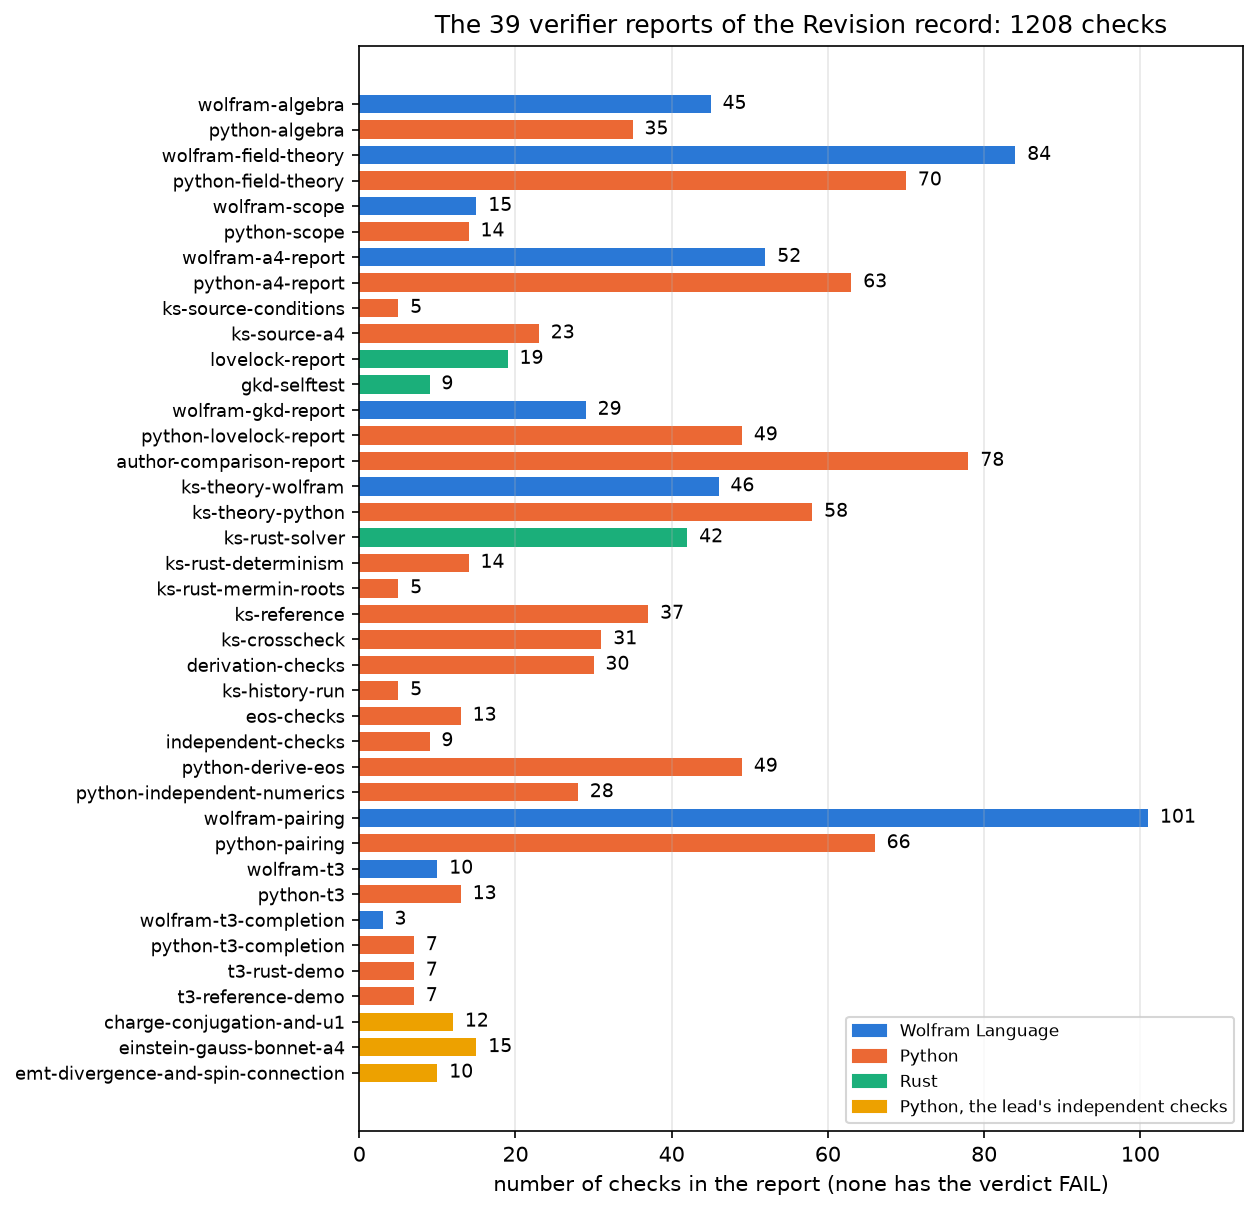

Figure 00c.1 saved as Revision/textbook/figures/00c_1_checks_by_report.png


In [7]:
from matplotlib.patches import Patch  # a coloured square for the legend

ENGINE_COLOURS = {"Wolfram": "#2a78d6", "Python": "#eb6834", "Rust": "#1baf7a",
                  "lead": "#eda100"}
ENGINE_NAMES = {"Wolfram": "Wolfram Language", "Python": "Python",
                "Rust": "Rust", "lead": "Python, the lead's independent checks"}

# The report with the most checks, and its number of checks.
largest = max((path for path, _ in REPORTS), key=lambda path: counted[path][1])
longest = counted[largest][1]
fig, ax = plt.subplots(figsize=(7.6, 9.4))
rows = np.arange(len(REPORTS))[::-1]  # the first report at the top
for row, (path, engine) in zip(rows, REPORTS):
    total = counted[path][1]
    ax.barh(row, total, height=0.72, color=ENGINE_COLOURS[engine])
    ax.text(total + 0.015 * longest, row, str(total), va="center", fontsize=9)
# The name of each report without its folder and without the ending .json:
names = [path.rsplit("/", 1)[1].removesuffix(".json") for path, _ in REPORTS]
ax.set_yticks(rows, labels=names, fontsize=8.5)
ax.set_xlim(0, 1.12 * longest)  # room for the longest bar and its number
ax.grid(False, axis="y")  # vertical grid lines only
ax.set_xlabel("number of checks in the report (none has the verdict FAIL)")
ax.set_title(f"The {len(REPORTS)} verifier reports of the Revision record: "
             f"{all_checks} checks")
ax.legend(handles=[Patch(color=ENGINE_COLOURS[e], label=ENGINE_NAMES[e])
                   for e in ENGINE_COLOURS], loc="lower right", fontsize=8)
largest_name = largest.rsplit("/", 1)[1]  # its file name without the folders
n_wolfram, n_python, n_rust, n_lead = (engine_totals[engine] for engine in
                                       ("Wolfram", "Python", "Rust", "lead"))
totals_text = (f"{n_wolfram} Wolfram Language, {n_python} Python, {n_rust} Rust "
               f"and {n_lead} lead checks")
save_figure(fig, "checks_by_report",
            f"The number of checks in each of the {len(REPORTS)} verifier reports "
            r"of the Revision record (horizontal axis, a count; one bar per report, "
            r"named on the vertical axis and grouped by folder: algebra, theory, "
            r"field equations for $a_4$, GKD and Lovelock with the comparison with "
            r"the author's outputs, Kohn-Sham, dark sector, pairing, lead checks). "
            r"The colour gives the engine: blue Wolfram Language, orange Python, "
            r"aqua Rust, yellow the lead's independent Python checks. Of the "
            f"{all_checks} checks ({totals_text}) {all_passed} have the verdict "
            f"PASS and {not_available} the verdict NOT-AVAILABLE (comparisons with "
            r"values that the author's notebook does not store); none FAILS. The "
            f"largest report is {largest_name} with {longest} checks.")

## 8. Two independent engines

For nine subjects the Revision record has two independent verifiers, one in
Wolfram Language and one in Python. The next cell draws, for each subject, the
number of checks of the two verifiers side by side. The two verifiers do not
check exactly the same list of statements (each also checks things the other does
not), so the numbers differ; the point is that two programs, written separately in
two different languages, both find the results of each subject correct.

subject                              Wolfram  Python
the gammas, Pin(4,4), Spin(4,4)           45      35
Lagrangians, field equations, EMT         84      70
scope of the non-triviality               15      14
field equations for a4                    52      63
GKD and the Lovelock tensors              29      49
Kohn-Sham theory                          46      58
pairing theorems T1, T2, Q               101      66
pairing theorem T3                        10      13
the completion of T3                       3       7


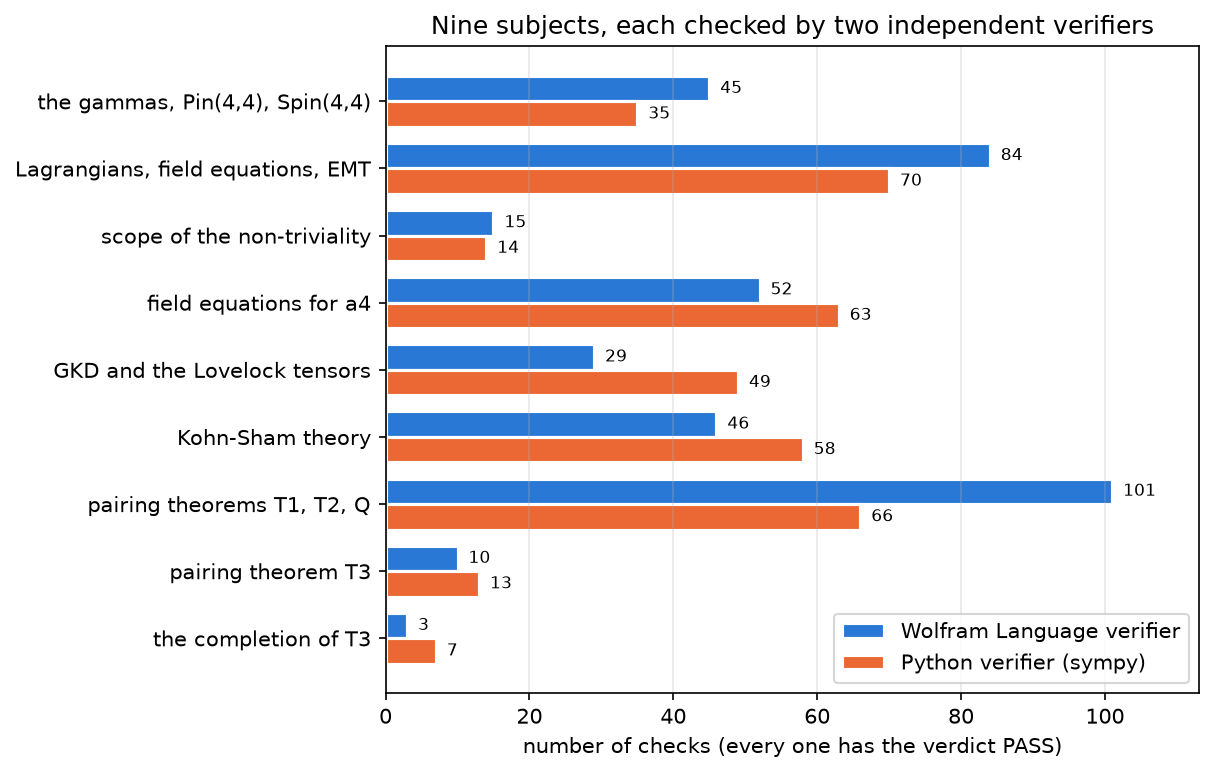

Figure 00c.2 saved as Revision/textbook/figures/00c_2_two_verifiers.png
RESULT checks of the Wolfram verifiers of the nine subjects = 385
RESULT checks of the Python verifiers of the nine subjects = 375
PASS each of the nine subjects has a Wolfram and a Python verifier


In [8]:
SUBJECTS = [  # (subject, Wolfram report, Python report)
    ("the gammas, Pin(4,4), Spin(4,4)", "algebra/reports/wolfram-algebra.json",
     "algebra/reports/python-algebra.json"),
    ("Lagrangians, field equations, EMT", "theory/reports/wolfram-field-theory.json",
     "theory/reports/python-field-theory.json"),
    ("scope of the non-triviality", "theory/reports/wolfram-scope.json",
     "theory/reports/python-scope.json"),
    ("field equations for a4", "field_equations_a4/reports/wolfram-a4-report.json",
     "field_equations_a4/reports/python-a4-report.json"),
    ("GKD and the Lovelock tensors", "gkd_lovelock/results/wolfram-gkd-report.json",
     "gkd_lovelock/results/python-lovelock-report.json"),
    ("Kohn-Sham theory", "kohn_sham/reports/ks-theory-wolfram.json",
     "kohn_sham/reports/ks-theory-python.json"),
    ("pairing theorems T1, T2, Q", "pairing/reports/wolfram-pairing.json",
     "pairing/reports/python-pairing.json"),
    ("pairing theorem T3", "pairing/kohn_sham/reports/wolfram-t3.json",
     "pairing/kohn_sham/reports/python-t3.json"),
    ("the completion of T3", "pairing/kohn_sham/reports/wolfram-t3-completion.json",
     "pairing/kohn_sham/reports/python-t3-completion.json"),
]
say("subject                              Wolfram  Python")
wolfram_numbers, python_numbers = [], []
for subject, wolfram, python in SUBJECTS:
    wolfram_numbers.append(counted["Revision/" + wolfram][1])
    python_numbers.append(counted["Revision/" + python][1])
    say(f"{subject:36} {wolfram_numbers[-1]:7d} {python_numbers[-1]:7d}")

widest = max(wolfram_numbers + python_numbers)  # the longest of the 18 bars
fig, ax = plt.subplots(figsize=(7.0, 5.6))
rows = np.arange(len(SUBJECTS))[::-1]
height = 0.38  # two bars in each row
ax.barh(rows + height / 2, wolfram_numbers, height, color="#2a78d6",
        edgecolor="white", linewidth=1.5, label="Wolfram Language verifier")
ax.barh(rows - height / 2, python_numbers, height, color="#eb6834",
        edgecolor="white", linewidth=1.5, label="Python verifier (sympy)")
for row, w, p in zip(rows, wolfram_numbers, python_numbers):
    ax.text(w + 0.015 * widest, row + height / 2, str(w), va="center", fontsize=8)
    ax.text(p + 0.015 * widest, row - height / 2, str(p), va="center", fontsize=8)
ax.set_yticks(rows, labels=[subject for subject, _, _ in SUBJECTS])
ax.set_xlim(0, 1.12 * widest)  # room for the longest bar and its number
ax.grid(False, axis="y")
ax.set_xlabel("number of checks (every one has the verdict PASS)")
ax.set_title("Nine subjects, each checked by two independent verifiers")
ax.legend(loc="lower right")
save_figure(fig, "two_verifiers",
            r"For each of nine subjects of the Revision record (vertical axis), "
            r"the number of checks of its Wolfram Language verifier (blue, upper "
            r"bar) and of its independent Python verifier (orange, lower bar); "
            r"horizontal axis a count. The two verifiers share no code; each also "
            r"checks statements that the other does not, so the numbers differ. "
            f"Together they hold {sum(wolfram_numbers)} Wolfram and "
            f"{sum(python_numbers)} Python checks, all PASS.")
report("checks of the Wolfram verifiers of the nine subjects", sum(wolfram_numbers))
report("checks of the Python verifiers of the nine subjects", sum(python_numbers))
check(all(w > 0 and p > 0 for w, p in zip(wolfram_numbers, python_numbers)),
      "each of the nine subjects has a Wolfram and a Python verifier")

## 9. The honesty ledger

The next cell writes the ledger: twenty rows, each with a statement of the book,
its label, a short note where one is needed, and the reports that verify it. Every
one of the 39 reports belongs to exactly one row. The five rows labelled HYPOTHESIS
or OPEN have no report: nothing in the record establishes them, and their notes
say why. Two rows of PROVED theorems name an assumption in their statement: the
pairing theorems T2 and T3 hold with the Z2 mirror (a choice of boundary
condition) ASSUMED. The row of the Kohn-Sham history of $a_4$ is labelled ASSUMED
although it has 28 checks: those checks show that the computed Kohn-Sham states
cannot be the source of that history in the field equations, so the history has
to be assumed (a *prescribed background*). Row 7, the comparison of the Revision's
curvature with the values that the author stored in his own notebook, has a note
as well: five of its comparisons could not be made (NOT-AVAILABLE).

Two rows are labelled COMPUTED because they rest on numerical computations.
Row 13: the theorem T3 is proved (row 12) and, in addition, demonstrated on
computed Kohn-Sham states of mass $+M$ and $-M$; a demonstration is not a proof.
Row 15: the author's dark-sector hypotheses were investigated; the investigation
derives exact identities, but its results, the equations of state that each field
can give, are computed numbers under stated assumptions about the observer. It
states what each field can and cannot produce; it does not establish the
hypotheses (row 16, HYPOTHESIS).

Several rows concern pairs of universes and matter and antimatter, and their words
are chosen with care. PROVED (rows 11 and 12) are exact maps between the solutions
of mass $+m$ and those of mass $-m$; the map T1 also reverses the charge, so a
solution and its image carry opposite charges. That our universe actually has
such a partner is a HYPOTHESIS (row 17: an idea of the universe and anti-universe
kind, not a result). PROVED (row 14) is the local conservation law of the charge:
no charge is made or destroyed at any point. That the total charge of one universe
stays constant is OPEN (row 18): it holds only if no charge flows through the
brane at $z = \pi/2$, a no-flux condition that is ASSUMED, not derived, and that
fails on the exact homogeneous solutions found later in the book. That the big
bang creates universes in pairs is not proved: no creation process, rate or
amplitude follows from the equations (row 19, OPEN). The theory as built has no
baryons (the particles of ordinary matter such as the proton), no process that
changes their number and no violation of the CP symmetry (the exchange of
particles and antiparticles combined with a mirror reflection; it must be violated
for matter to win over antimatter), so it does not produce the excess of matter
over antimatter that we observe. What does produce it is a question that neither
the record nor the book answers (row 20, OPEN).

The cell prints the ledger and the notes, and checks that every report is used
exactly once; that the HYPOTHESIS and OPEN rows have a note and no report, and
every other row has reports; that only row 7 has checks that are not PASS, its
five NOT-AVAILABLE comparisons; and it counts the labels.

In [9]:
R = "Revision/"
K = R + "pairing/kohn_sham/reports/"  # the folder of the T3 reports
D = R + "dark_sector/"  # the folder of the dark-sector reports
LEDGER = [  # (statement, label, note, the reports that verify it)
    ("the gammas, C, Gamma, B; Pin(4,4) and Spin(4,4)", "PROVED", "",
     [R + "algebra/reports/wolfram-algebra.json",
      R + "algebra/reports/python-algebra.json"]),
    ("Lagrangians, field equations, EMT, quantisation", "PROVED", "",
     [R + "theory/reports/wolfram-field-theory.json",
      R + "theory/reports/python-field-theory.json"]),
    ("the exact scope of the non-triviality", "PROVED", "",
     [R + "theory/reports/wolfram-scope.json",
      R + "theory/reports/python-scope.json"]),
    ("EMT conservation identities; the spin connection", "PROVED", "",
     [R + "lead_checks/reports/emt-divergence-and-spin-connection.json"]),
    ("the field equations for a4", "PROVED", "",
     [R + "field_equations_a4/reports/wolfram-a4-report.json",
      R + "field_equations_a4/reports/python-a4-report.json",
      R + "lead_checks/reports/einstein-gauss-bonnet-a4.json"]),
    ("GKD and the three Lovelock tensors", "PROVED", "",
     [R + "gkd_lovelock/results/lovelock-report.json",
      R + "gkd_lovelock/results/gkd-selftest.json",
      R + "gkd_lovelock/results/wolfram-gkd-report.json",
      R + "gkd_lovelock/results/python-lovelock-report.json"]),
    ("the curvature agrees with the author's stored outputs", "PROVED",
     "5 of 78 comparisons NOT-AVAILABLE: the author's notebook stores no value",
     [R + "gkd_lovelock/comparison/author-comparison-report.json"]),
    ("Kohn-Sham theory: blocks, rescaling, exchange", "PROVED", "",
     [R + "kohn_sham/reports/ks-theory-wolfram.json",
      R + "kohn_sham/reports/ks-theory-python.json"]),
    ("Kohn-Sham states along the deflating history", "COMPUTED", "",
     [R + "kohn_sham/reports/ks-rust-solver.json",
      R + "kohn_sham/reports/ks-reference.json",
      R + "kohn_sham/reports/ks-crosscheck.json",
      R + "kohn_sham/reports/ks-rust-determinism.json",
      R + "kohn_sham/reports/ks-rust-mermin-roots.json"]),
    ("the Kohn-Sham history of a4 is a prescribed background", "ASSUMED", "",
     [R + "field_equations_a4/reports/ks-source-conditions.json",
      R + "field_equations_a4/ks_source/reports/ks-source-a4.json"]),
    ("pairing T1, T2 (Z2 mirror ASSUMED) and Q", "PROVED", "",
     [R + "pairing/reports/wolfram-pairing.json",
      R + "pairing/reports/python-pairing.json"]),
    ("T3 and its completion (Z2 mirror ASSUMED): +M and -M", "PROVED", "",
     [K + "wolfram-t3.json", K + "python-t3.json",
      K + "wolfram-t3-completion.json", K + "python-t3-completion.json"]),
    ("T3 shown on computed Kohn-Sham states (not a proof)", "COMPUTED", "",
     [K + "t3-rust-demo.json", K + "t3-reference-demo.json"]),
    ("charge conjugation C, Gamma C; the local U(1) law", "PROVED", "",
     [R + "lead_checks/reports/charge-conjugation-and-u1.json"]),
    ("the dark-sector investigation: what each field gives", "COMPUTED", "",
     [D + "dirac16complex/reports/derivation-checks.json",
      D + "dirac16complex/reports/ks-history-run.json",
      D + "dirac16complex/reports/eos-checks.json",
      D + "dirac16complex/reports/independent-checks.json",
      D + "dirac16complex00/reports/python-derive-eos.json",
      D + "dirac16complex00/reports/python-independent-numerics.json"]),
    ("a time-varying dark sector from the fields", "HYPOTHESIS",
     "investigated (row 15): results stated, not established", []),
    ("our universe has a partner of opposite charge", "HYPOTHESIS",
     "the T1 maps exist; that a partner exists is not shown", []),
    ("the total charge Q of one universe is constant", "OPEN",
     "holds only with no flux through the brane (ASSUMED, not derived)", []),
    ("the big bang creates universes in pairs", "OPEN",
     "not proved: no creation process, rate or amplitude", []),
    ("what produces the excess of matter over antimatter", "OPEN",
     "the theory as built does not produce it", []),
]
say("row label       passed of all  statement")
row_passed, row_totals = [], []
for number, (statement, label, note, paths) in enumerate(LEDGER, 1):
    passed = sum(counted[path][0] for path in paths)
    total = sum(counted[path][1] for path in paths)
    row_passed.append(passed)
    row_totals.append(total)
    say(f"{number:3d} {label:10} {passed:7d} of {total:3d}  {statement}")
say("The notes of the rows:")
for number, (statement, label, note, paths) in enumerate(LEDGER, 1):
    if note:  # the HYPOTHESIS and OPEN rows, and row 7
        say(f"{number:3d} {label:10} {note}")
used = sorted(path for _, _, _, paths in LEDGER for path in paths)
check(used == sorted(path for path, _ in REPORTS),
      f"every one of the {len(REPORTS)} reports belongs to exactly one row")
check(all((label in ("HYPOTHESIS", "OPEN")) == (paths == [] and note != "")
          for _, label, note, paths in LEDGER)
      and all(paths != [] for _, label, _, paths in LEDGER
              if label not in ("HYPOTHESIS", "OPEN")),
      "OPEN and HYPOTHESIS rows have a note and no report; the others have reports")
not_all_pass = [number for number, passed, total
                in zip(range(1, len(LEDGER) + 1), row_passed, row_totals)
                if passed != total]  # the rows with a check that is not PASS
check(not_all_pass == [7] and row_totals[6] - row_passed[6] == not_available
      and "NOT-AVAILABLE" in LEDGER[6][2],
      f"only row 7 has checks that are not PASS: its {not_available} "
      "NOT-AVAILABLE comparisons")
labels = [label for _, label, _, _ in LEDGER]
check([labels.count(name) for name in
       ("PROVED", "COMPUTED", "ASSUMED", "HYPOTHESIS", "OPEN")] == [11, 3, 1, 2, 3],
      "the ledger: 11 PROVED, 3 COMPUTED, 1 ASSUMED, 2 HYPOTHESIS and 3 OPEN rows")

row label       passed of all  statement
  1 PROVED          80 of  80  the gammas, C, Gamma, B; Pin(4,4) and Spin(4,4)
  2 PROVED         154 of 154  Lagrangians, field equations, EMT, quantisation
  3 PROVED          29 of  29  the exact scope of the non-triviality
  4 PROVED          10 of  10  EMT conservation identities; the spin connection
  5 PROVED         130 of 130  the field equations for a4
  6 PROVED         106 of 106  GKD and the three Lovelock tensors
  7 PROVED          73 of  78  the curvature agrees with the author's stored outputs
  8 PROVED         104 of 104  Kohn-Sham theory: blocks, rescaling, exchange
  9 COMPUTED       129 of 129  Kohn-Sham states along the deflating history
 10 ASSUMED         28 of  28  the Kohn-Sham history of a4 is a prescribed background
 11 PROVED         167 of 167  pairing T1, T2 (Z2 mirror ASSUMED) and Q
 12 PROVED          33 of  33  T3 and its completion (Z2 mirror ASSUMED): +M and -M
 13 COMPUTED        14 of  14  T3 shown on compu

The next cell draws the ledger: one bar per row, with the row's number and
statement written just above it, its length the number of checks of the row's
reports, its colour the label. The rows labelled HYPOTHESIS and OPEN have no bar;
their label and their note are written where the bar would begin.

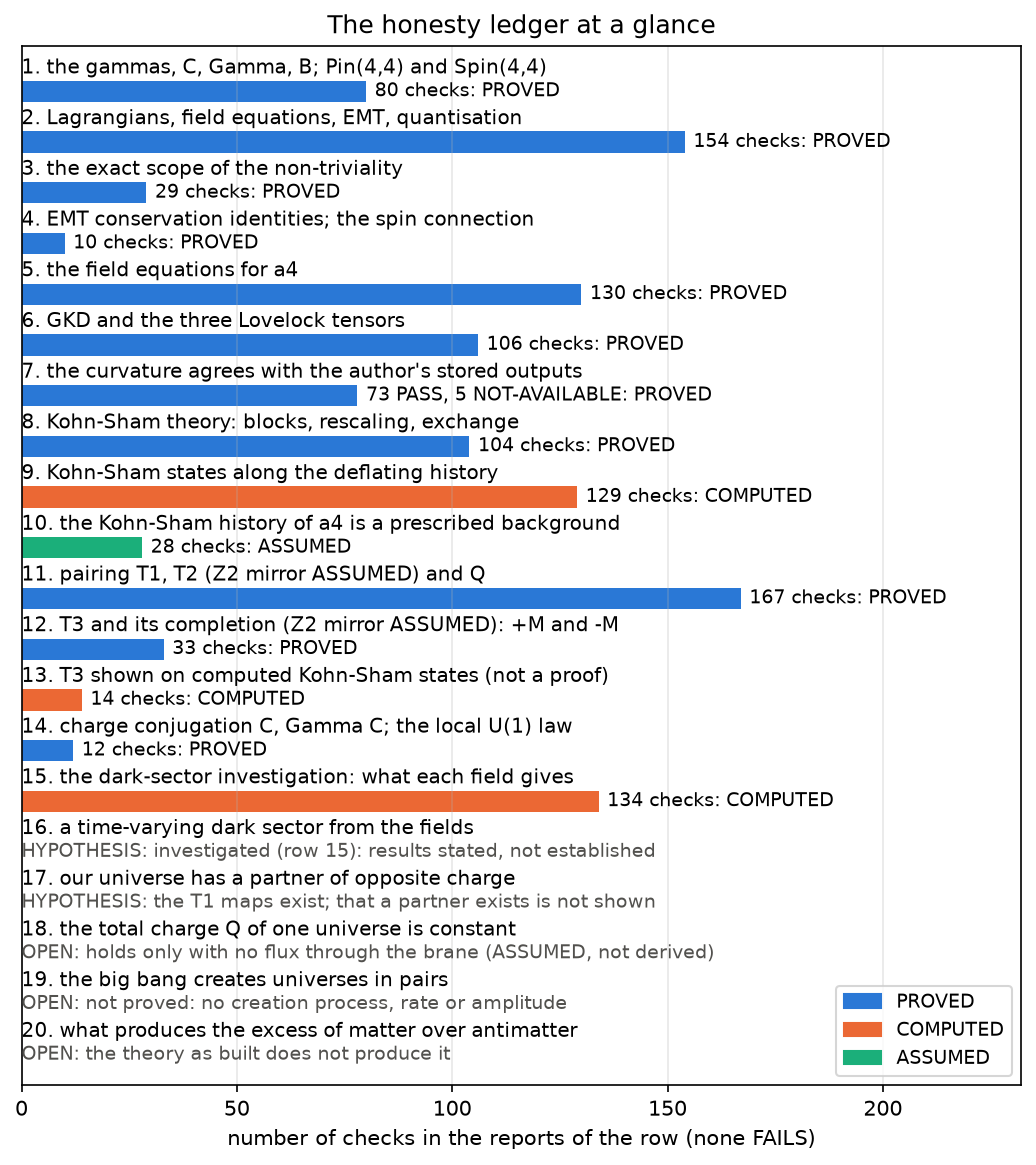

Figure 00c.3 saved as Revision/textbook/figures/00c_3_ledger.png


In [10]:
LABEL_COLOURS = {"PROVED": "#2a78d6", "COMPUTED": "#eb6834", "ASSUMED": "#1baf7a"}
widest = max(row_totals)  # the row with the most checks
fig, ax = plt.subplots(figsize=(8.6, 9.0))
rows = np.arange(len(LEDGER))[::-1]  # the first row of the ledger at the top
for number, row, (statement, label, note, paths), passed, total in zip(
        range(1, len(LEDGER) + 1), rows, LEDGER, row_passed, row_totals):
    # The statement is written just above its bar (va="bottom": the text starts
    # at the given height and extends upwards).
    ax.text(0, row + 0.26, f"{number}. {statement}", va="bottom", fontsize=9.5)
    if total > 0:
        ax.barh(row, total, height=0.42, color=LABEL_COLOURS[label])
        if passed == total:
            after = f"{total} checks: {label}"
        else:  # row 7: say how many checks are NOT-AVAILABLE
            after = f"{passed} PASS, {total - passed} NOT-AVAILABLE: {label}"
        ax.text(total + 0.012 * widest, row, after, va="center", fontsize=9)
    else:  # no report: the label and the note, in grey
        ax.text(0, row, f"{label}: {note}", va="center", fontsize=9,
                color="#52514e")
ax.set_yticks([])  # the statements are written above the bars instead
ax.set_xlim(0, 1.39 * widest)  # room for the longest bar and the text after it
ax.set_ylim(-0.6, len(LEDGER) - 0.1)
ax.grid(False, axis="y")
ax.set_xlabel("number of checks in the reports of the row (none FAILS)")
ax.set_title("The honesty ledger at a glance")
ax.legend(handles=[Patch(color=colour, label=label_name)
                   for label_name, colour in LABEL_COLOURS.items()],
          loc="lower right", fontsize=9)
save_figure(fig, "ledger",
            r"The honesty ledger of the book at a glance: one row per main "
            r"statement (written above its bar), the length of its bar the number of "
            r"checks in the reports that verify it (horizontal axis, a count), the "
            r"colour its label: blue PROVED, orange COMPUTED, aqua ASSUMED. Every "
            r"check is PASS except five NOT-AVAILABLE comparisons of row 7. The "
            f"ASSUMED row has {row_totals[9]} checks, which show why the Kohn-Sham "
            r"history of $a_4$ must be assumed. The last five rows have no bar, "
            r"because no check of the record establishes them: two hypotheses (a "
            r"time-varying dark sector, investigated in row 15 but not established; "
            r"a partner universe of opposite charge) and three open questions (a "
            r"constant total charge of one universe, which needs an assumed "
            r"condition at the brane; the creation of universes in pairs, not "
            r"proved; what produces the excess of matter "
            r"over antimatter, which the theory as built does not produce).")

The pairing record states in its own words what the pairing theorems do NOT
establish: the key `not_established` of the report
Revision/pairing/reports/python-pairing.json is a list of twelve sentences. The
next cell prints all twelve. The first says that nothing in the equations creates a
universe or a pair of universes. This is why the ledger labels the statement "the
big bang creates universes in pairs" OPEN.

In [11]:
PAIRING = "Revision/pairing/reports/python-pairing.json"
not_established = read_report(PAIRING)["not_established"]  # a list of sentences
for number, sentence in enumerate(not_established, 1):
    say(f"{number:2d}. {sentence}")
check_reproduces(len(not_established) == 12
                 and not_established[0].startswith("No creation process"),
                 "the pairing record lists 12 things it does not establish, "
                 "the first: no creation process",
                 f"{PAIRING}, key not_established")

 1. No creation process: nothing in these equations produces a universe, a pair of
    universes or a change of the number of universes; no transition between 'no universe'
    and 'two universes' is described.
 2. No rate, probability or amplitude for creating a pair is derived; no wave function of
    the universe, path integral or tunnelling computation is part of these theorems.
 3. No conservation law forces pairing: the theorems are symmetries (maps between
    solutions); a single universe with mass +m is an equally valid solution of the field
    equations without its partner.
 4. The vanishing total energy-momentum and charge of a pair (T1) is an identity for a
    field configuration and its image (classical bilinears, or one operator and its
    image); it is not a cancellation between two independently quantised universes
    (Q.no_cancellation_independent_universes).
 5. T2 does not reverse the sign of the energy-momentum tensor: the mirror universe of
    mass -m has the 

## 10. Fingerprints

A sha256 fingerprint is computed from the bytes of a file (or of a text) by the
function `hashlib.sha256`; `.hexdigest()` writes it as 64 hexadecimal characters.
The next cell computes the fingerprints of two texts that differ only in the case
of one letter, and shows that the two fingerprints have nothing in common.

Then it measures this for many changes: it takes one sentence of 115 characters,
changes each character in turn to the next character of the alphabet of the
computer (a to b, a blank to an exclamation mark, and so on), and counts how many
of the 64 characters of the fingerprint change. If the new fingerprint were a
random string, each of its 64 characters would equal the old one with
probability $1/16$, so on average $64 \cdot 15/16 = 60$ characters would change.
The cell draws the 115 counts as a histogram (a bar chart of how often each count
occurs).

Universes in Pairs:
    3bf948a39ff61a48d1538293b76acbbbd85359fce5b1d824efb5329208185f38
Universes in pairs:
    27d89acd6238771ac751cd99a3578c7f3b65ffbba3cdc2ec0e116ec01ce95fe9
RESULT characters of the sentence = 115
RESULT changed characters of the fingerprint: smallest, mean, largest = 54, 60.03, 64


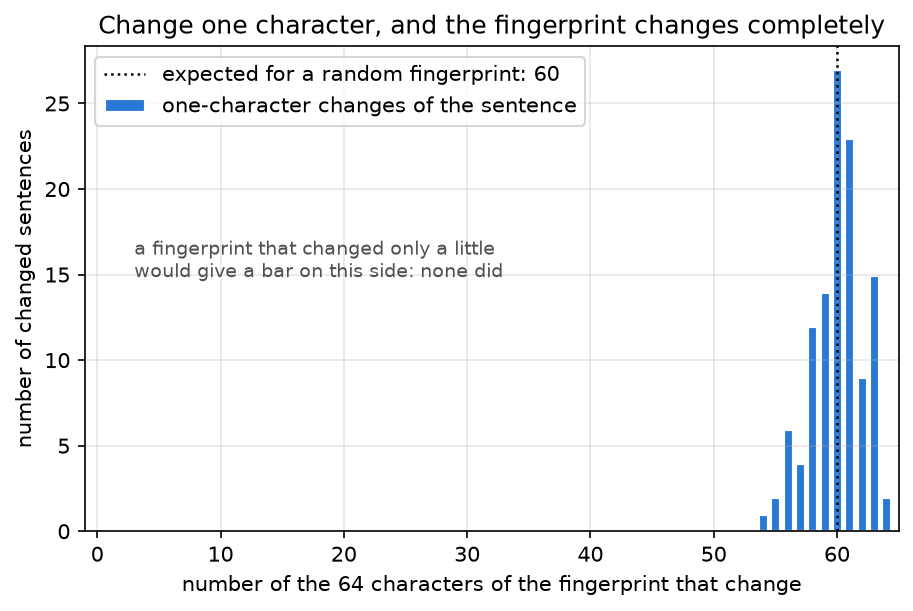

Figure 00c.4 saved as Revision/textbook/figures/00c_4_fingerprints.png
PASS all 115 one-character changes alter more than half of the fingerprint


In [12]:
def text_fingerprint(text):
    """The sha256 fingerprint of a text (encoded as UTF-8 bytes)."""
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


for text in ("Universes in Pairs", "Universes in pairs"):
    digest = text_fingerprint(text)
    say(f"{text}:")
    say(f"    {digest}")

SENTENCE = ("The rule above every other rule of this book is honesty: it never "
            "writes proved for a statement that is not proved.")
original = text_fingerprint(SENTENCE)
changed_characters = []  # for each position: how many of the 64 characters change
for position in range(len(SENTENCE)):
    letter = SENTENCE[position]
    altered = SENTENCE[:position] + chr(ord(letter) + 1) + SENTENCE[position + 1:]
    new = text_fingerprint(altered)
    changed_characters.append(sum(1 for a, b in zip(original, new) if a != b))
counts = np.array(changed_characters)
report("characters of the sentence", len(SENTENCE))
report("changed characters of the fingerprint: smallest, mean, largest",
       f"{counts.min()}, {counts.mean():.2f}, {counts.max()}")

values, how_often = np.unique(counts, return_counts=True)  # each count, how often
fig, ax = plt.subplots()
ax.bar(values, how_often, width=0.8, color="#2a78d6", edgecolor="white",
       linewidth=1.5, label="one-character changes of the sentence")
ax.axvline(60, color="black", linewidth=1.2, linestyle=":",
           label="expected for a random fingerprint: 60")
ax.set_xlim(-1, 65)
# "\n" inside a string starts a new line of the text.
ax.text(3, 0.55 * how_often.max(), "a fingerprint that changed only a little\n"
        "would give a bar on this side: none did", color="#52514e", fontsize=9)
ax.set_xlabel("number of the 64 characters of the fingerprint that change")
ax.set_ylabel("number of changed sentences")
ax.set_title("Change one character, and the fingerprint changes completely")
ax.legend(loc="upper left")
save_figure(fig, "fingerprints",
            r"How much a sha256 fingerprint changes when one character of a text "
            r"changes: for each of the 115 characters of one sentence, the "
            r"character was replaced by the next one and the number of the 64 "
            r"hexadecimal characters of the fingerprint that changed was counted; "
            r"horizontal axis that number (0 to 64), vertical axis how many of the "
            r"115 altered sentences gave it. Every change altered between "
            f"{counts.min()} and {counts.max()} of the 64 characters, on average "
            f"{counts.mean():.2f}, as for a random string (dotted line at 60): none "
            f"of the {len(counts)} one-character changes left the fingerprint "
            r"nearly the same.")
check(counts.min() > 32 and abs(counts.mean() - 60.0) < 1.0,
      f"all {len(counts)} one-character changes alter more than half of the "
      "fingerprint")

The reports of the Revision record write down the fingerprints of the files they
read. The report of the Wolfram check of GKD and the Lovelock tensors records 15
(its keys `inputSha256` and `sourceSha256`: the result files, the Rust sources and
its own Wolfram sources), the Python check of the Lovelock tensors 2 (key
`inputsSha256`), and five Kohn-Sham reports write 7 more into the details of their
checks, in the form `(sha256 95d8cbdd...)`, either in full (64 characters) or only
the first 16 characters. The next cell collects all 24, computes the fingerprints of
today's files, compares them (a shortened fingerprint with the beginning of
today's), and prints a table. When all agree, every one of these reports was
written from exactly the files that are in the repository today.

In [13]:
def file_fingerprint(path):
    """The sha256 fingerprint of the bytes of the repository file path."""
    return hashlib.sha256(repository_file(path).read_bytes()).hexdigest()


RECORDED = []  # (report, file, recorded fingerprint)
GKD = "Revision/gkd_lovelock/results/wolfram-gkd-report.json"
gkd = read_report(GKD)
for path, value in {**gkd["inputSha256"], **gkd["sourceSha256"]}.items():
    RECORDED.append((GKD, path, value))
LOVELOCK = "Revision/gkd_lovelock/results/python-lovelock-report.json"
for name, value in read_report(LOVELOCK)["inputsSha256"].items():
    RECORDED.append((LOVELOCK, "Revision/gkd_lovelock/results/" + name, value))
IN_DETAILS = [  # (report, check, the file whose fingerprint the detail holds)
    ("ks-theory-wolfram.json", "fixture_input", "algebra/gammas.json"),
    ("ks-theory-python.json", "fixture_input", "algebra/reports/python-gammas.json"),
    ("ks-reference.json", "theory_input_coefficients", "kohn_sham/ks-theory.json"),
    ("ks-rust-solver.json", "theory_input_coefficients", "kohn_sham/ks-theory.json"),
    ("ks-rust-solver.json", "gamma_fixture_numeric", "algebra/gammas.json"),
    ("ks-rust-solver.json", "thermo_mu_vs_40digit_roots",
     "kohn_sham/solver/tools/mermin-roots-40digit.json"),
    ("ks-crosscheck.json", "problem_definition_identical",
     "kohn_sham/ks-theory.json"),
]
for name, check_name, path in IN_DETAILS:
    report_path = "Revision/kohn_sham/reports/" + name
    detail = next(entry["detail"] for entry in read_report(report_path)["checks"]
                  if entry["name"] == check_name)
    value = re.search(r"\(sha256 ([0-9a-f]{16,64})\)", detail).group(1)
    RECORDED.append((report_path, "Revision/" + path, value))

changed = []  # files whose fingerprint today differs from the recorded one
for report_path, path, value in RECORDED:
    same = file_fingerprint(path).startswith(value)  # a full or shortened value
    if not same:
        changed.append(path)
    status = "same" if same else "CHANGED"
    short_path = path.removeprefix("Revision/")  # the path without Revision/
    report_name = report_path.rsplit("/", 1)[1]  # the file name of the report
    say(f"{status:7} {short_path:52} {report_name}")
recorded_gammas = next(value for report_path, path, value in RECORDED
                       if report_path.endswith("ks-theory-wolfram.json"))
today_gammas = file_fingerprint("Revision/algebra/gammas.json")
say("Revision/algebra/gammas.json, recorded in ks-theory-wolfram.json and today:")
say(f"    {recorded_gammas}")
say(f"    {today_gammas}")
report("recorded fingerprints compared", len(RECORDED))
check_reproduces(len(RECORDED) == 24 and changed == [],
                 "the 24 recorded fingerprints equal the files of today",
                 f"{GKD}, keys inputSha256 and sourceSha256, and five further reports")

same    gkd_lovelock/results/PROVENANCE_OF_THE_COMPUTATION.md wolfram-gkd-report.json
same    gkd_lovelock/results/curvature.json                  wolfram-gkd-report.json
same    gkd_lovelock/results/lovelock-tensors.json           wolfram-gkd-report.json
same    gkd_lovelock/results/lovelock-report.json            wolfram-gkd-report.json
same    gkd_lovelock/code/Cargo.toml                         wolfram-gkd-report.json
same    gkd_lovelock/code/src/geometry.rs                    wolfram-gkd-report.json
same    gkd_lovelock/code/src/gkd.rs                         wolfram-gkd-report.json
same    gkd_lovelock/code/src/lib.rs                         wolfram-gkd-report.json
same    gkd_lovelock/code/src/lovelock.rs                    wolfram-gkd-report.json
same    gkd_lovelock/code/src/main.rs                        wolfram-gkd-report.json
same    gkd_lovelock/code/src/output.rs                      wolfram-gkd-report.json
same    gkd_lovelock/code/src/poly.rs                        wol

## 11. The last check

The last cell checks that the four figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [14]:
figure_names = ["00c_1_checks_by_report.png", "00c_2_two_verifiers.png",
                "00c_3_ledger.png", "00c_4_fingerprints.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "the four figure files of this notebook exist")
all_checks_passed()

PASS the four figure files of this notebook exist
ALL 18 CHECKS PASSED (notebook 00c)


## 12. What this notebook showed

- A search of the whole folder Revision finds 39 verifier reports, the 39 of our
  list. No check has the verdict FAIL: every check is PASS except five
  comparisons with values that the author's own notebook does not store, whose
  verdict is NOT-AVAILABLE; section 7 prints how many checks there are, in all and
  per engine (Wolfram Language, Python, Rust and the lead's independent Python
  checks).
- Each report states the same totals that we counted, and the counts quoted in
  the file Revision/README.md, in the Kohn-Sham cross-check and in the
  dark-sector summary file are the same as well.
- Nine subjects are checked by two independent verifiers, one in Wolfram Language
  and one in Python.
- Every report belongs to exactly one row of the honesty ledger. Fifteen rows have
  reports (eleven PROVED, three COMPUTED, one ASSUMED). The charge obeys a local
  conservation law (PROVED); that the total charge of one universe stays constant
  is OPEN, because it needs an assumed condition at the brane. Two rows are
  HYPOTHESIS (a time-varying dark sector, investigated but not established; a
  partner universe of opposite charge) and three are OPEN: the constancy of the
  total charge, whether the big bang creates universes in pairs (not proved), and
  what produces the excess of matter over antimatter (the theory as built does not
  produce it). The pairing record itself lists twelve things it does not
  establish, the first being any creation process.
- Each of the 115 one-character changes of a sentence changed more than half of
  the 64 characters of its sha256 fingerprint, 60.03 on average, as for a random
  string; and the 24 fingerprints that the reports recorded for their input files
  equal those of today's files.